In [1]:
import pandas as pd
import re

# Load your results file
df = pd.read_csv('results\parse_tree_distances.csv')

# Function to extract language code from 'augment_xx_xx'
def extract_lang(col):
    match = re.match(r'augment_([a-z]{2})_', col)
    return match.group(1) if match else col

# Build the rename dictionary for relevant columns
rename_dict = {col: extract_lang(col) for col in df.columns if col.startswith('augment_')}
df.rename(columns=rename_dict, inplace=True)

# Save the cleaned file
df.to_csv('results\parse_tree_distances_langcode.csv', index=False)


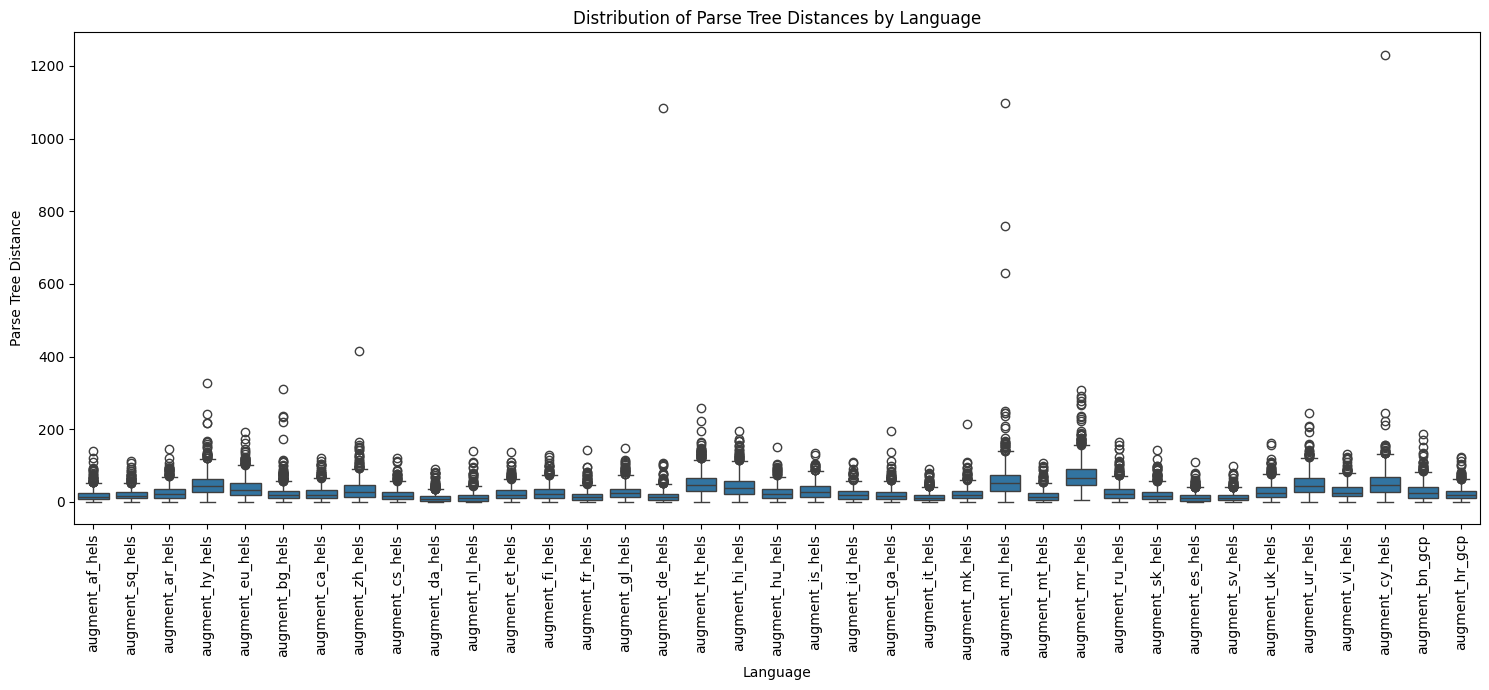

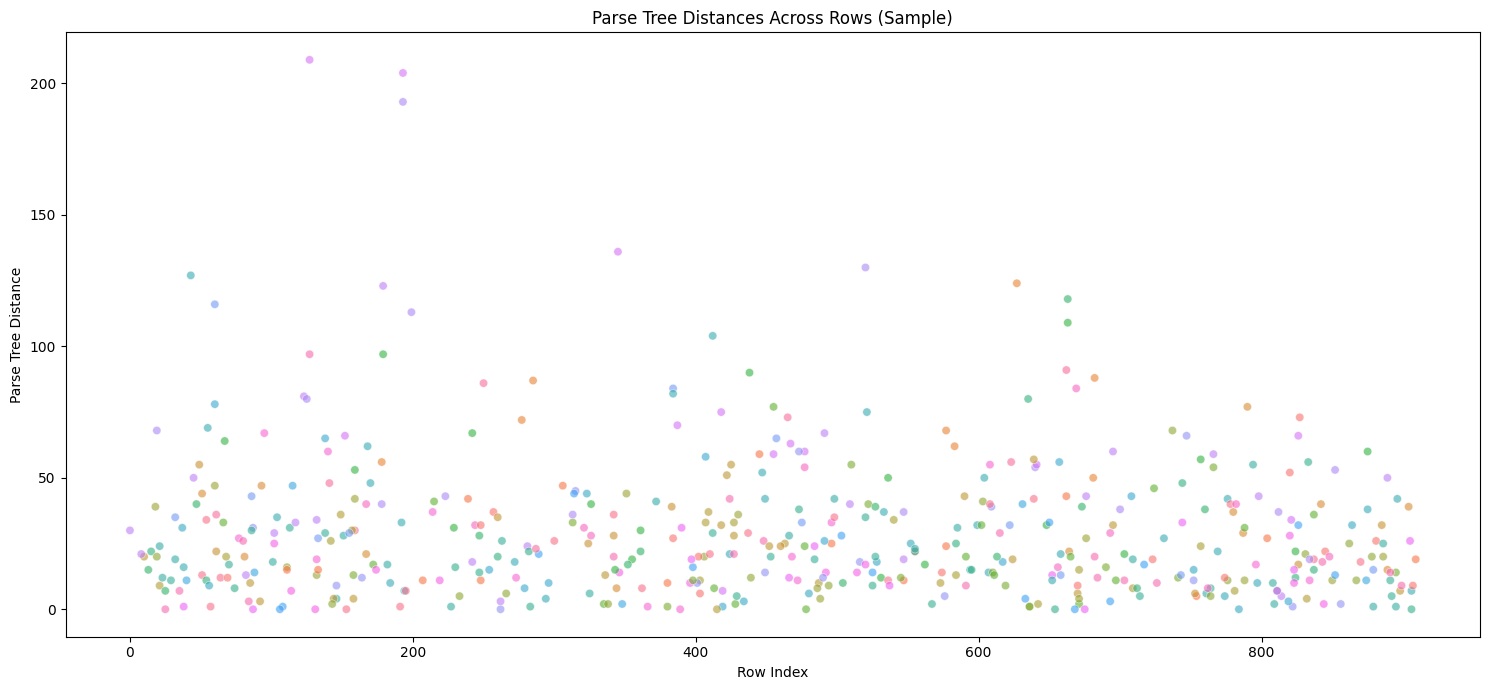

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the results
results_df = pd.read_csv('results\parse_tree_distances_langcode.csv')

# Select parse tree distance columns
augment_distance_cols = [col for col in results_df.columns if col.endswith('_parse_tree_distance')]

# Melt to long format for plotting
melted_df = results_df.melt(
    id_vars=['row', 'text'],
    value_vars=augment_distance_cols,
    var_name='language',
    value_name='parse_tree_distance'
)
melted_df['language'] = melted_df['language'].str.replace('_parse_tree_distance', '')
melted_df = melted_df.dropna(subset=['parse_tree_distance'])

# Boxplot
plt.figure(figsize=(15, 7))
sns.boxplot(data=melted_df, x='language', y='parse_tree_distance')
plt.xticks(rotation=90)
plt.title('Distribution of Parse Tree Distances by Language')
plt.ylabel('Parse Tree Distance')
plt.xlabel('Language')
plt.tight_layout()
plt.show()

# Scatter plot (sample up to 500 points for clarity)
plt.figure(figsize=(15, 7))
sns.scatterplot(
    data=melted_df.sample(min(500, len(melted_df))),
    x='row', y='parse_tree_distance', hue='language', legend=None, alpha=0.6
)
plt.title('Parse Tree Distances Across Rows (Sample)')
plt.ylabel('Parse Tree Distance')
plt.xlabel('Sample Original Texts')
plt.tight_layout()
plt.show()
